# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Jaya Jaya Institut

- Nama:Anthony Saputra
- Email:anthonysa20028@gmail.com
- Id Dicoding:-

## Persiapan

### Menyiapkan library yang dibutuhkan

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

### Menyiapkan data yang akan diguankan

## Data Understanding

In [2]:
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/data.csv',sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")

Jumlah baris   : 4424
Jumlah kolom   : 37


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [6]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns.tolist()

['Marital_status',
 'Application_mode',
 'Application_order',
 'Course',
 'Daytime_evening_attendance',
 'Previous_qualification',
 'Previous_qualification_grade',
 'Nacionality',
 'Mothers_qualification',
 'Fathers_qualification',
 'Mothers_occupation',
 'Fathers_occupation',
 'Admission_grade',
 'Displaced',
 'Educational_special_needs',
 'Debtor',
 'Tuition_fees_up_to_date',
 'Gender',
 'Scholarship_holder',
 'Age_at_enrollment',
 'International',
 'Curricular_units_1st_sem_credited',
 'Curricular_units_1st_sem_enrolled',
 'Curricular_units_1st_sem_evaluations',
 'Curricular_units_1st_sem_approved',
 'Curricular_units_1st_sem_grade',
 'Curricular_units_1st_sem_without_evaluations',
 'Curricular_units_2nd_sem_credited',
 'Curricular_units_2nd_sem_enrolled',
 'Curricular_units_2nd_sem_evaluations',
 'Curricular_units_2nd_sem_approved',
 'Curricular_units_2nd_sem_grade',
 'Curricular_units_2nd_sem_without_evaluations',
 'Unemployment_rate',
 'Inflation_rate',
 'GDP',
 'Status']

In [9]:
df['Status'].value_counts()



Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [10]:
df['Status'].value_counts(normalize=True).mul(100).round(2)

Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

### eda 

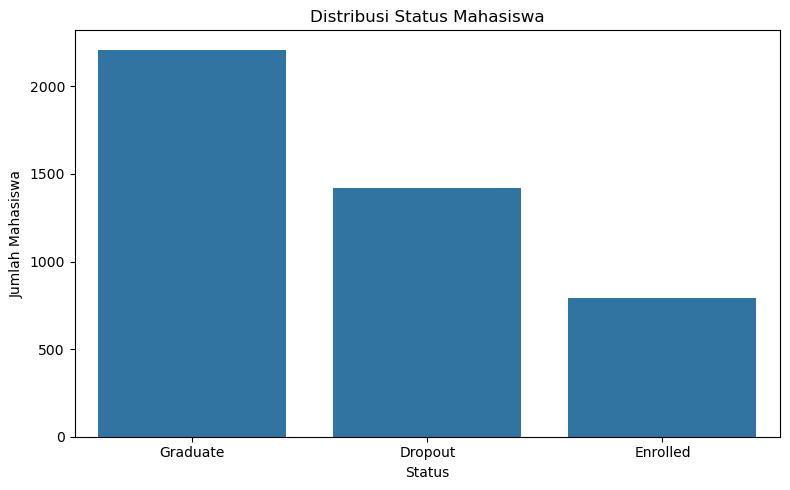

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Status',
    order=df['Status'].value_counts().index
)

plt.title('Distribusi Status Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
plt.tight_layout()
plt.show()

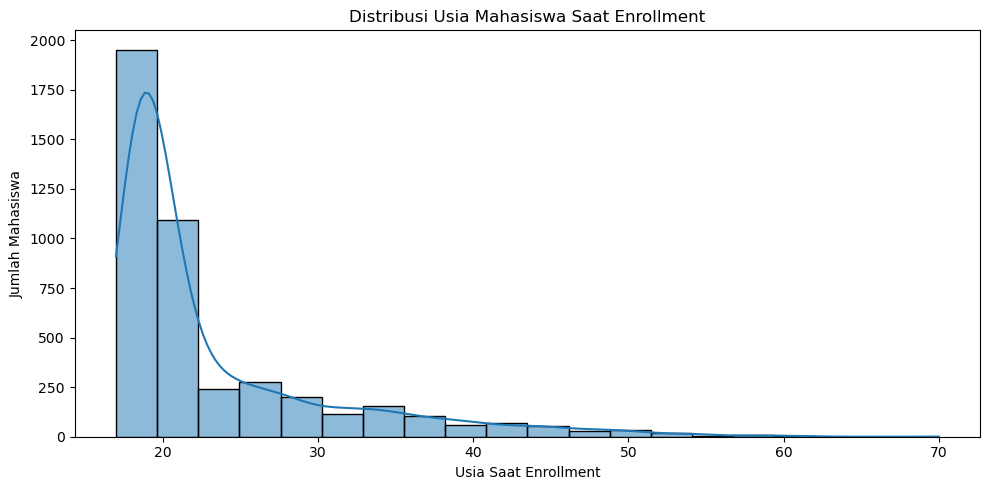

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Age_at_enrollment',
    bins=20,
    kde=True
)

plt.title('Distribusi Usia Mahasiswa Saat Enrollment')
plt.xlabel('Usia Saat Enrollment')
plt.ylabel('Jumlah Mahasiswa')
plt.tight_layout()
plt.show()

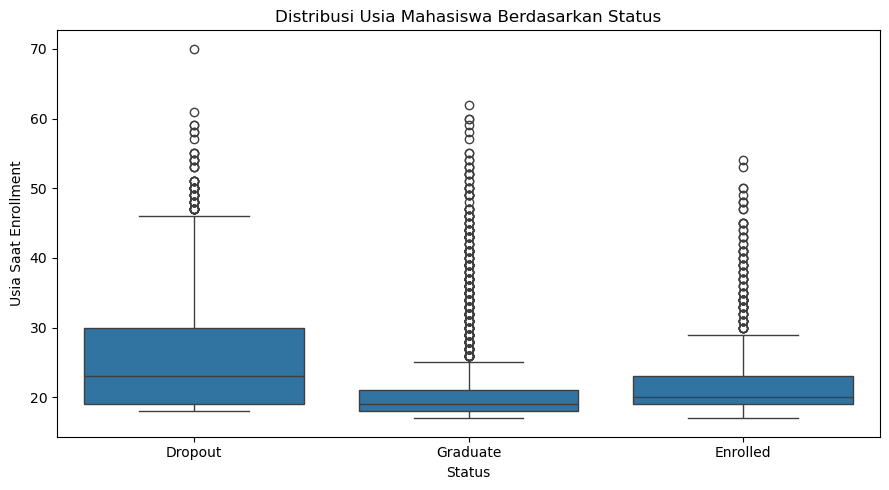

In [13]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Status',
    y='Age_at_enrollment'
)

plt.title('Distribusi Usia Mahasiswa Berdasarkan Status')
plt.xlabel('Status')
plt.ylabel('Usia Saat Enrollment')
plt.tight_layout()
plt.show()

In [14]:
df.groupby('Status')['Age_at_enrollment'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,count,mean,median,min,max
Status,,,,,
Dropout,1421,26.07,23.0,18,70
Enrolled,794,22.37,20.0,17,54
Graduate,2209,21.78,19.0,17,62


In [15]:
gender_map = {
    0: 'Female',
    1: 'Male'
}

df['Gender_Label'] = df['Gender'].map(gender_map)
gender_status = pd.crosstab(
    df['Gender_Label'],
    df['Status'],
    normalize='index'
).mul(100).round(2)

gender_status

Status,Dropout,Enrolled,Graduate
Gender_Label,,,
Female,25.10,16.98,57.91
Male,45.05,19.73,35.22


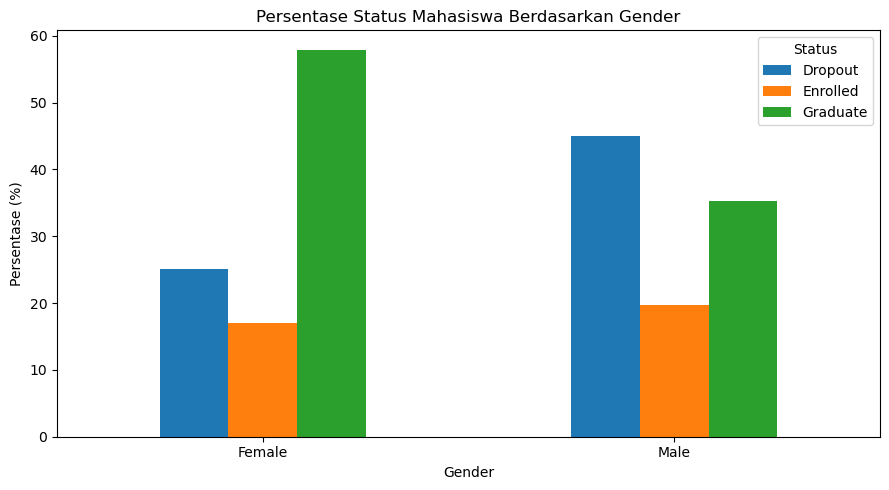

In [16]:
gender_status.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Persentase Status Mahasiswa Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [17]:
tuition_map = {
    0: 'Not up to date',
    1: 'Up to date'
}

df['Tuition_Status'] = df['Tuition_fees_up_to_date'].map(tuition_map)
tuition_status = pd.crosstab(
    df['Tuition_Status'],
    df['Status'],
    normalize='index'
).mul(100).round(2)

tuition_status

Status,Dropout,Enrolled,Graduate
Tuition_Status,,,
Not up to date,86.55,7.95,5.49
Up to date,24.74,19.30,55.95


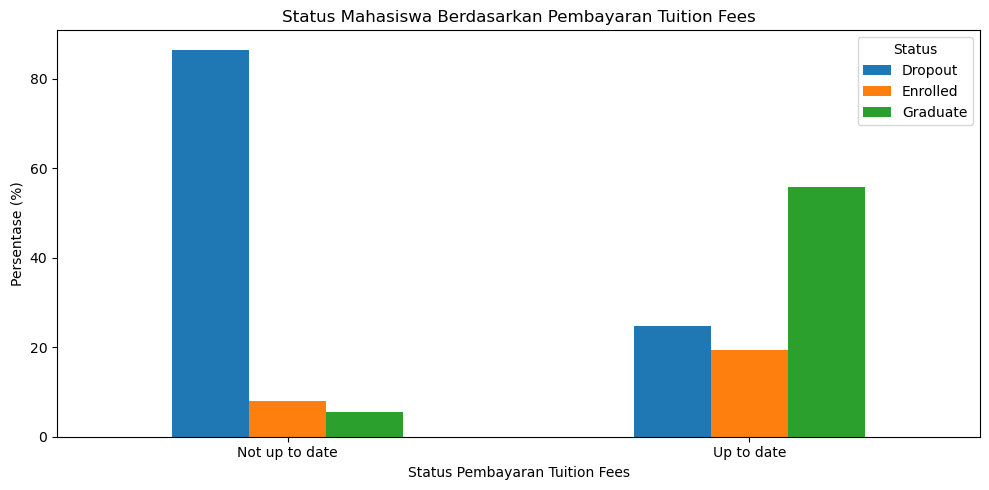

In [18]:
tuition_status.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Status Mahasiswa Berdasarkan Pembayaran Tuition Fees')
plt.xlabel('Status Pembayaran Tuition Fees')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [19]:
debtor_map = {
    0: 'No',
    1: 'Yes'
}

df['Debtor_Label'] = df['Debtor'].map(debtor_map)

debtor_status = pd.crosstab(
    df['Debtor_Label'],
    df['Status'],
    normalize='index'
).mul(100).round(2)

debtor_status

Status,Dropout,Enrolled,Graduate
Debtor_Label,,,
No,28.28,17.95,53.76
Yes,62.03,17.89,20.08


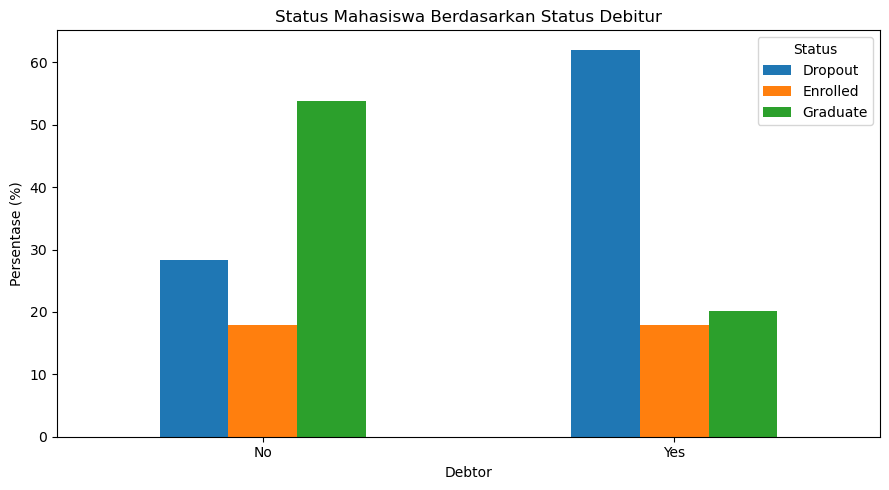

In [20]:
debtor_status.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Status Mahasiswa Berdasarkan Status Debitur')
plt.xlabel('Debtor')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [21]:
scholarship_map = {
    0: 'No',
    1: 'Yes'
}

df['Scholarship_Label'] = df['Scholarship_holder'].map(scholarship_map)

scholarship_status = pd.crosstab(
    df['Scholarship_Label'],
    df['Status'],
    normalize='index'
).mul(100).round(2)

scholarship_status

Status,Dropout,Enrolled,Graduate
Scholarship_Label,,,
No,38.71,19.97,41.32
Yes,12.19,11.83,75.98


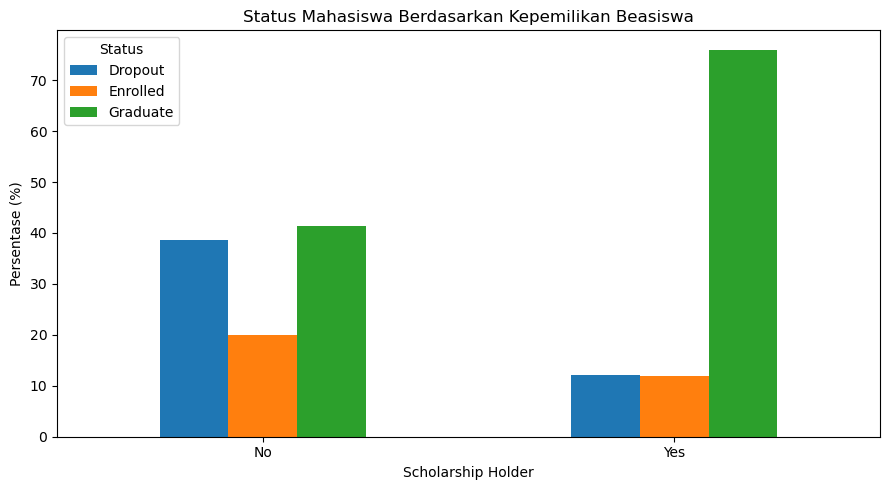

In [22]:
scholarship_status.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Status Mahasiswa Berdasarkan Kepemilikan Beasiswa')
plt.xlabel('Scholarship Holder')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [24]:
cols_curricular = [
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade'
]
curricular_mean = df.groupby('Status')[cols_curricular].mean().round(2)
curricular_mean

,Curricular_units_1st_sem_approved,Curricular_units_2nd_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_grade
Status,,,,
Dropout,2.55,1.94,7.26,5.90
Enrolled,4.32,4.06,11.13,11.12
Graduate,6.23,6.18,12.64,12.70


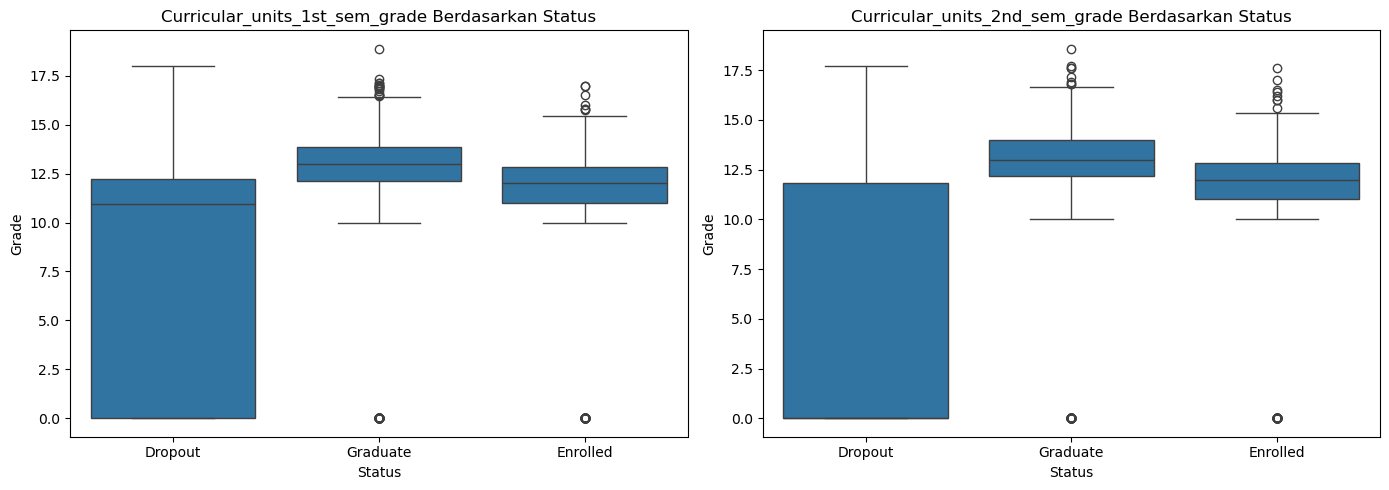

In [35]:
academic_cols = [
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, academic_cols):
    sns.boxplot(
        data=df,
        x='Status',
        y=col,
        ax=ax
    )
    
    ax.set_title(f'{col} Berdasarkan Status')
    ax.set_xlabel('Status')
    ax.set_ylabel('Grade')

plt.tight_layout()
plt.show()

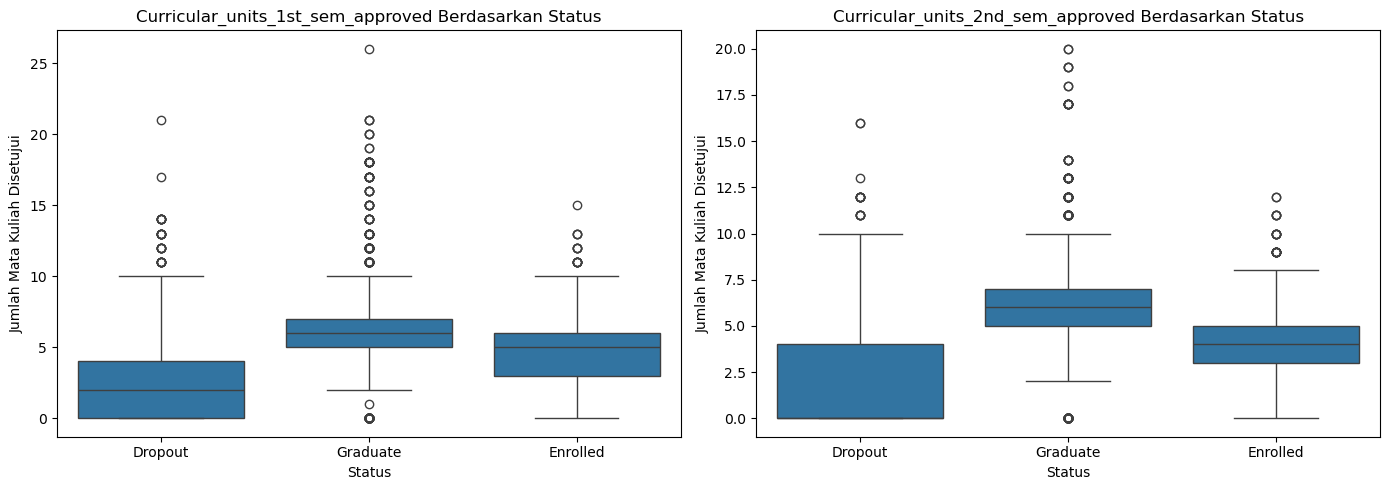

In [36]:
approved_cols = [
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, approved_cols):
    sns.boxplot(
        data=df,
        x='Status',
        y=col,
        ax=ax
    )
    
    ax.set_title(f'{col} Berdasarkan Status')
    ax.set_xlabel('Status')
    ax.set_ylabel('Jumlah Mata Kuliah Disetujui')

plt.tight_layout()
plt.show()

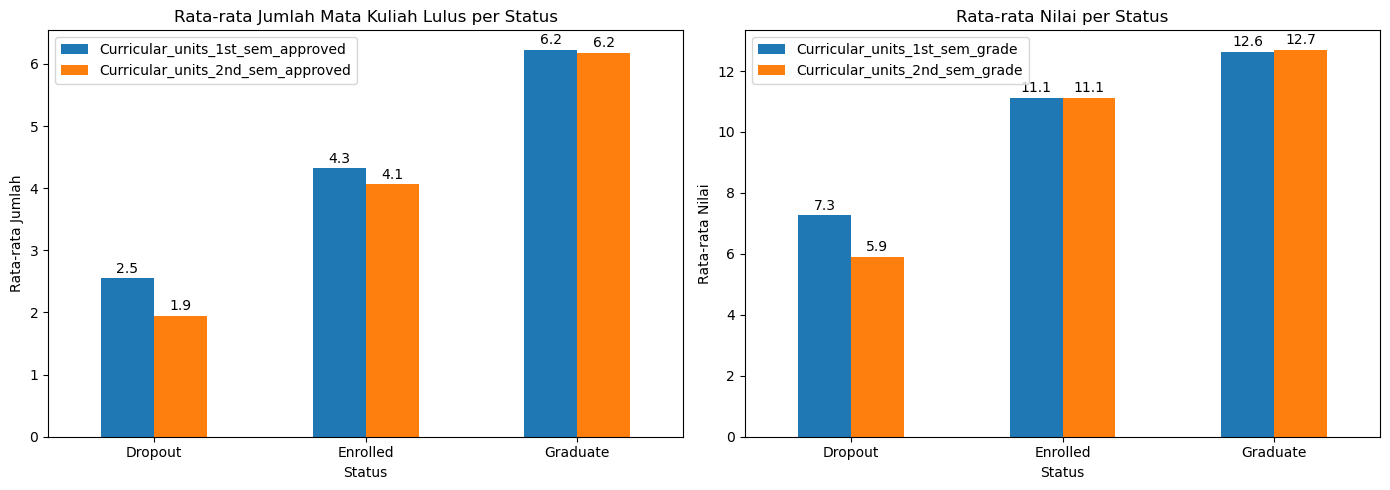

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

curricular_mean[['Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved']].plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Rata-rata Jumlah Mata Kuliah Lulus per Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Rata-rata Jumlah')
axes[0].tick_params(axis='x', rotation=0)

curricular_mean[['Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']].plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('Rata-rata Nilai per Status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Rata-rata Nilai')
axes[1].tick_params(axis='x', rotation=0)

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=2)

plt.tight_layout()
plt.show()

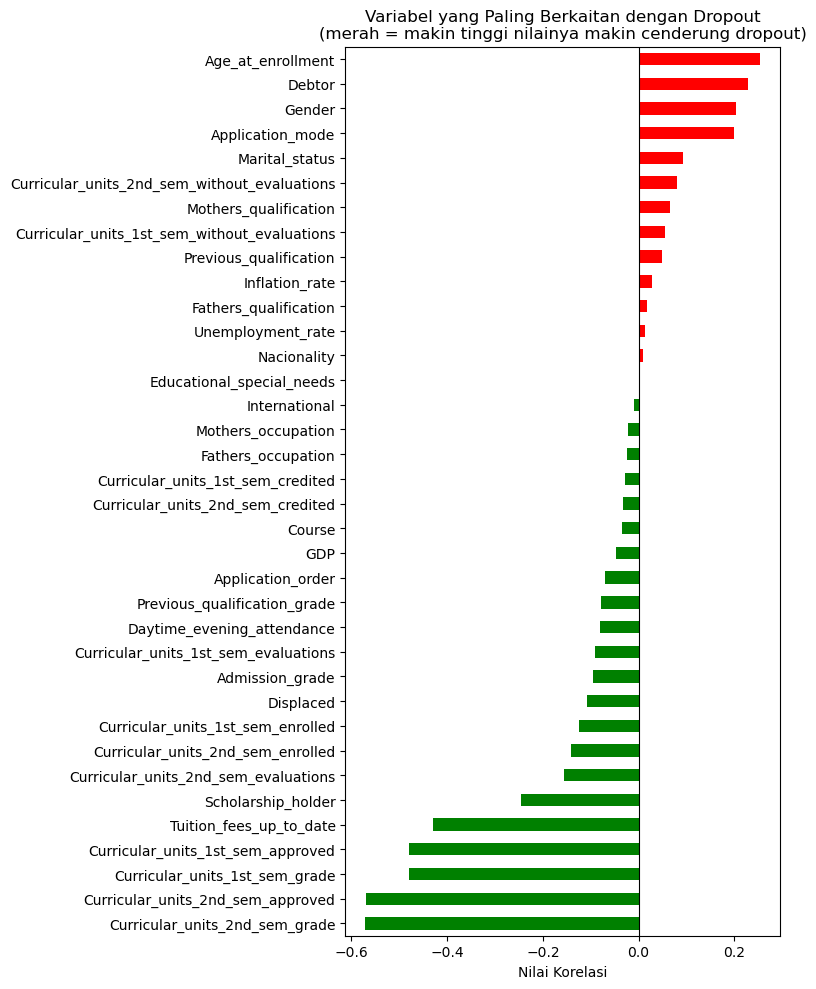

In [26]:
df['Is_Dropout'] = (df['Status'] == 'Dropout').astype(int)

corr_dropout = (
    df.select_dtypes(include=[np.number])
    .corr()['Is_Dropout']
    .drop('Is_Dropout')
    .sort_values()
)

plt.figure(figsize=(8, 10))
corr_dropout.plot(kind='barh', color=['red' if v > 0 else 'green' for v in corr_dropout])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Variabel yang Paling Berkaitan dengan Dropout\n(merah = makin tinggi nilainya makin cenderung dropout)')
plt.xlabel('Nilai Korelasi')
plt.tight_layout()
plt.show()

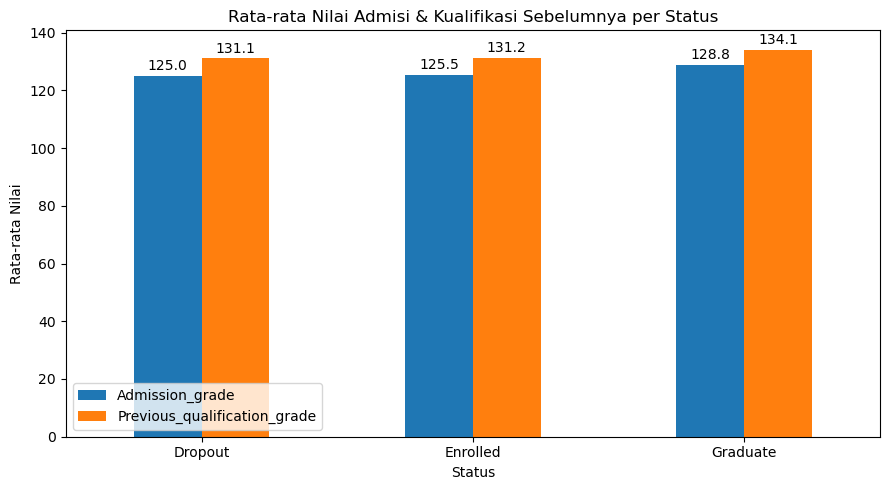

In [27]:
grade_cols = ['Admission_grade', 'Previous_qualification_grade']
grade_mean = df.groupby('Status')[grade_cols].mean().round(1)

ax = grade_mean.plot(kind='bar', figsize=(9, 5))
plt.title('Rata-rata Nilai Admisi & Kualifikasi Sebelumnya per Status')
plt.xlabel('Status')
plt.ylabel('Rata-rata Nilai')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2)
plt.tight_layout()
plt.show()

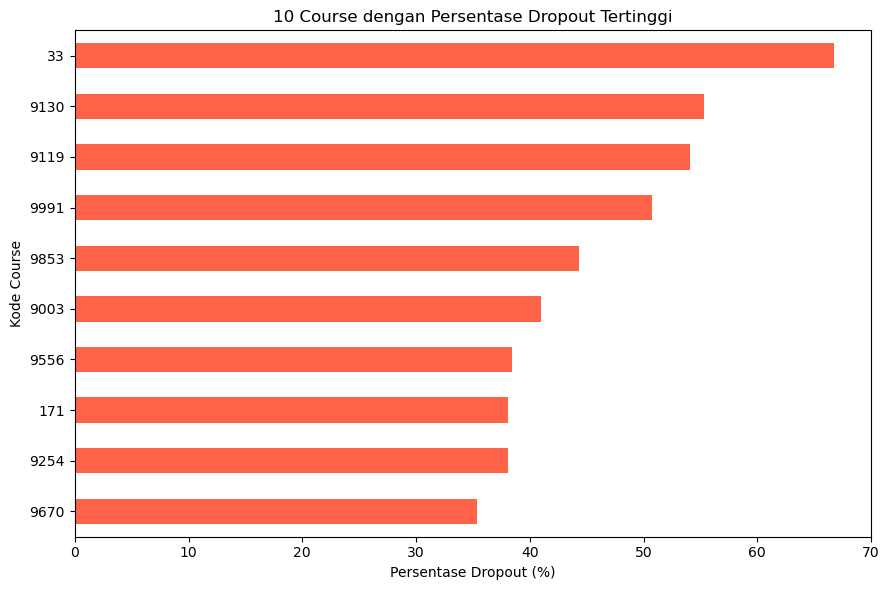

In [28]:
course_dropout = (
    df.groupby('Course')['Is_Dropout']
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
course_dropout.head(10).plot(kind='barh', color='tomato')
plt.gca().invert_yaxis()
plt.title('10 Course dengan Persentase Dropout Tertinggi')
plt.xlabel('Persentase Dropout (%)')
plt.ylabel('Kode Course')
plt.tight_layout()
plt.show()

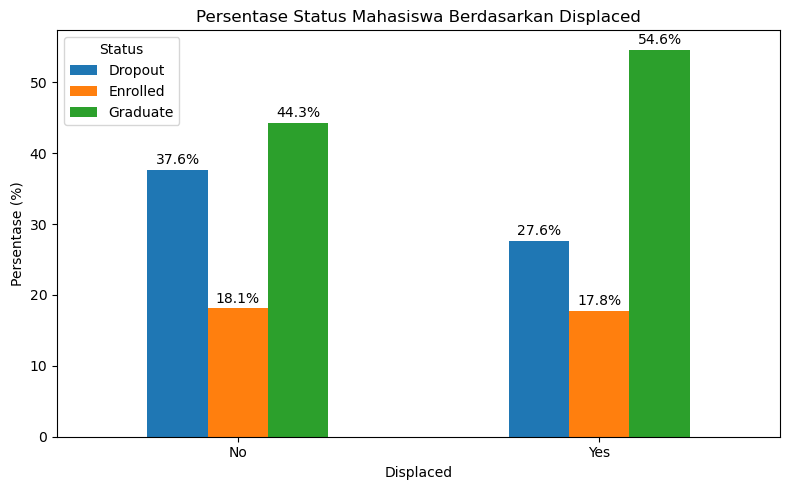

In [29]:
displaced_map = {0: 'No', 1: 'Yes'}
df['Displaced_Label'] = df['Displaced'].map(displaced_map)
displaced_status = pd.crosstab(df['Displaced_Label'], df['Status'], normalize='index').mul(100).round(1)

ax = displaced_status.plot(kind='bar', figsize=(8, 5))
plt.title('Persentase Status Mahasiswa Berdasarkan Displaced')
plt.xlabel('Displaced')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)
plt.tight_layout()
plt.show()

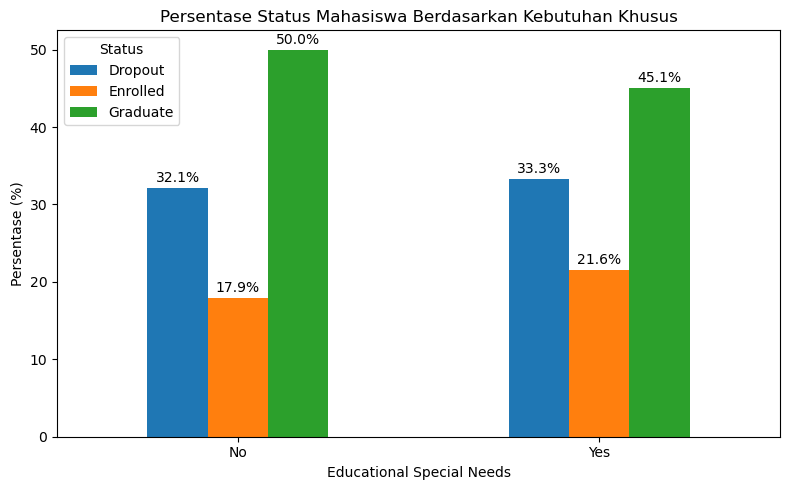

In [30]:
special_needs_map = {0: 'No', 1: 'Yes'}
df['Special_Needs_Label'] = df['Educational_special_needs'].map(special_needs_map)
special_needs_status = pd.crosstab(df['Special_Needs_Label'], df['Status'], normalize='index').mul(100).round(1)

ax = special_needs_status.plot(kind='bar', figsize=(8, 5))
plt.title('Persentase Status Mahasiswa Berdasarkan Kebutuhan Khusus')
plt.xlabel('Educational Special Needs')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)
plt.tight_layout()
plt.show()

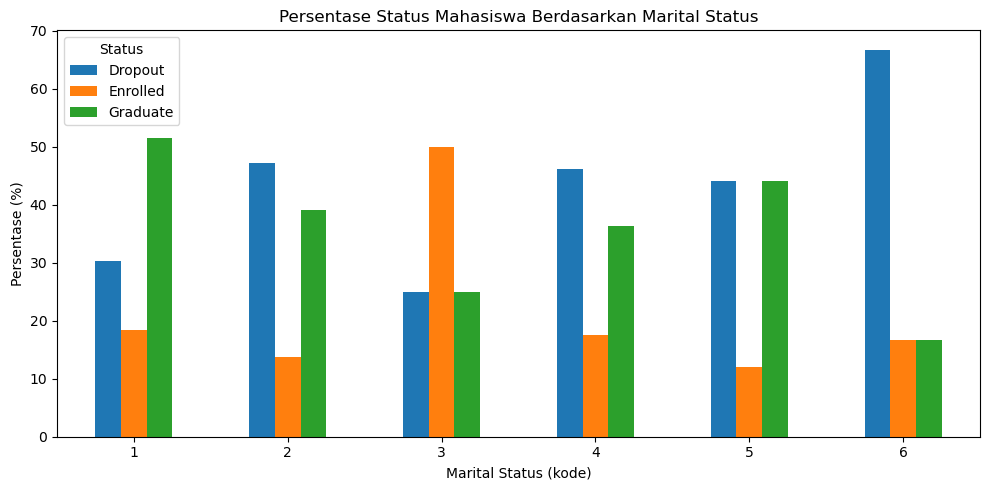

In [31]:
marital_status_ct = pd.crosstab(df['Marital_status'], df['Status'], normalize='index').mul(100).round(1)

ax = marital_status_ct.plot(kind='bar', figsize=(10, 5))
plt.title('Persentase Status Mahasiswa Berdasarkan Marital Status')
plt.xlabel('Marital Status (kode)')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [33]:
df[['Admission_grade', 'Previous_qualification_grade', 'Age_at_enrollment']].describe().round(1)

,Admission_grade,Previous_qualification_grade,Age_at_enrollment
count,4424.0,4424.0,4424.0
mean,127.0,132.6,23.3
std,14.5,13.2,7.6
min,95.0,95.0,17.0
25%,117.9,125.0,19.0
50%,126.1,133.1,20.0
75%,134.8,140.0,25.0
max,190.0,190.0,70.0


## Data Preparation / Preprocessing

In [37]:
X = df.drop(columns=['Status'])
y = df['Status']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (4424, 43)
Shape y: (4424,)


In [38]:
eda_columns = [
    'Gender_Label',
    'Tuition_Status',
    'Debtor_Label',
    'Scholarship_Label',
    'Displaced_Label',
    'Special_Needs_Label',
    'Is_Dropout'
]

X = df.drop(columns=['Status'] + eda_columns, errors='ignore')
y = df['Status']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (4424, 36)
Shape y: (4424,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training :", X_train.shape)
print("Data testing  :", X_test.shape)

Data training : (3539, 36)
Data testing  : (885, 36)


In [44]:
categorical_features = [
    'Marital_status',
    'Application_mode',
    'Course',
    'Daytime_evening_attendance',
    'Previous_qualification',
    'Nacionality',
    'Mothers_qualification',
    'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Displaced',
    'Educational_special_needs',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'International'
]

numeric_features = [
    'Application_order',
    'Previous_qualification_grade',
    'Admission_grade',
    'Age_at_enrollment',
    'Curricular_units_1st_sem_credited',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited',
    'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Curricular_units_2nd_sem_without_evaluations',
    'Unemployment_rate',
    'Inflation_rate',
    'GDP'
]

print("Jumlah fitur kategorikal:", len(categorical_features))
print("Jumlah fitur numerik:", len(numeric_features))

Jumlah fitur kategorikal: 17
Jumlah fitur numerik: 19


In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [47]:
print("Distribusi target - Training")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribusi target - Testing")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Distribusi target - Training
Status
Graduate    49.93
Dropout     32.13
Enrolled    17.94
Name: proportion, dtype: float64

Distribusi target - Testing
Status
Graduate    49.94
Dropout     32.09
Enrolled    17.97
Name: proportion, dtype: float64


## Modeling

In [52]:
models = {
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            random_state=42,
            class_weight='balanced',
            verbosity=-1
        ))
    ]),

    'SVM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', SVC(
            kernel='rbf',
            C=1.0,
            probability=True,
            class_weight='balanced',
            random_state=42
        ))
    ])
}

In [53]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} selesai dilatih.')

Random Forest selesai dilatih.
LightGBM selesai dilatih.
SVM selesai dilatih.


## Evaluation

In [56]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.764972,0.748690,0.764972,0.747005
1,LightGBM,0.748023,0.755461,0.748023,0.750631
2,SVM,0.731073,0.763689,0.731073,0.741686


In [57]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred,
        target_names=['Dropout', 'Enrolled', 'Graduate']
    ))

Random Forest
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       284
    Enrolled       0.57      0.32      0.41       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.72      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885

LightGBM
              precision    recall  f1-score   support

     Dropout       0.79      0.71      0.75       284
    Enrolled       0.48      0.55      0.51       159
    Graduate       0.83      0.84      0.84       442

    accuracy                           0.75       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.75      0.75       885

SVM
              precision    recall  f1-score   support

     Dropout       0.83      0.68      0.75       284
    Enrolled       0.43      0.62      0.50       159
    Graduate       0.84      0.81      0.82     

In [58]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(y_test, y_pred))

Random Forest
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       284
    Enrolled       0.57      0.32      0.41       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.72      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885

LightGBM
              precision    recall  f1-score   support

     Dropout       0.79      0.71      0.75       284
    Enrolled       0.48      0.55      0.51       159
    Graduate       0.83      0.84      0.84       442

    accuracy                           0.75       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.75      0.75       885

SVM
              precision    recall  f1-score   support

     Dropout       0.83      0.68      0.75       284
    Enrolled       0.43      0.62      0.50       159
    Graduate       0.84      0.81      0.82     

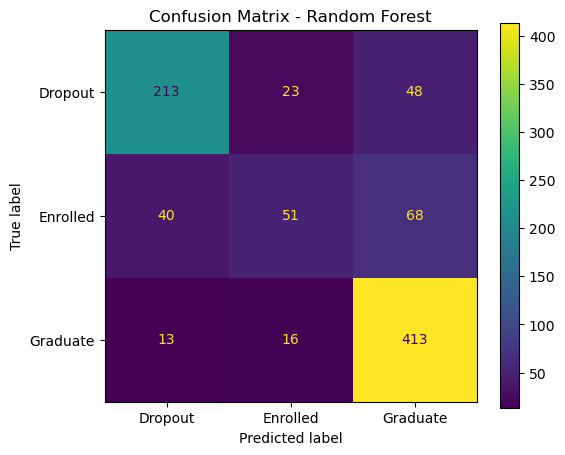

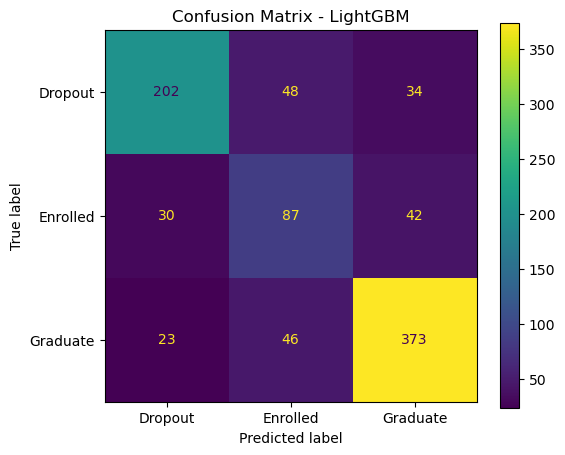

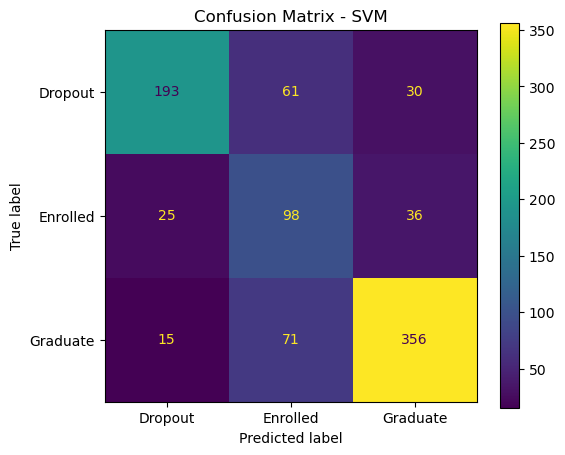

In [59]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax)

    ax.set_title(f'Confusion Matrix - {name}')
    plt.show()

In [60]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    print(
        f"{name}: "
        f"Recall Dropout = {report['Dropout']['recall']:.4f}, "
        f"F1-Score Dropout = {report['Dropout']['f1-score']:.4f}"
    )

Random Forest: Recall Dropout = 0.7500, F1-Score Dropout = 0.7745
LightGBM: Recall Dropout = 0.7113, F1-Score Dropout = 0.7495
SVM: Recall Dropout = 0.6796, F1-Score Dropout = 0.7466


In [63]:
os.makedirs('model', exist_ok=True)
best_model = models['Random Forest']
joblib.dump(best_model, 'model/student_dropout_model.pkl')
print("Model berhasil disimpan.")

Model berhasil disimpan.


In [64]:
rf_model = models['Random Forest']
preprocessor_fitted = rf_model.named_steps['preprocessor']
rf_classifier = rf_model.named_steps['model']
feature_names = preprocessor_fitted.get_feature_names_out()
importance = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
13,num__Curricular_units_2nd_sem_approved,0.090437
14,num__Curricular_units_2nd_sem_grade,0.077166
7,num__Curricular_units_1st_sem_approved,0.061421
8,num__Curricular_units_1st_sem_grade,0.056504
12,num__Curricular_units_2nd_sem_evaluations,0.040290
6,num__Curricular_units_1st_sem_evaluations,0.036966
2,num__Admission_grade,0.036768
3,num__Age_at_enrollment,0.032723
1,num__Previous_qualification_grade,0.032483
237,cat__Tuition_fees_up_to_date_1,0.023132


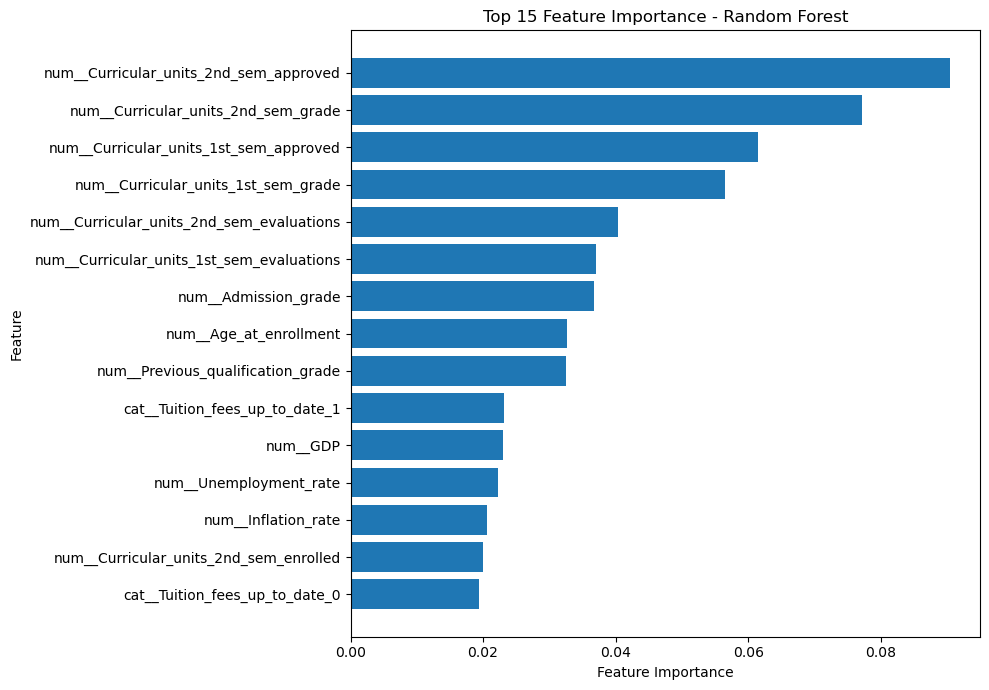

In [65]:
top_features = feature_importance_df.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance - Random Forest')

plt.tight_layout()
plt.show()